In [2]:
import sys
sys.path.append('/home/mark.bishop/Documents/Kea')
import kea
from kea.simulator import mff
from kea.statistics.statfunc import statfunc_numba, mpi_acf
from kea.utils import plotting
import numpy as np

NO MPI


In [3]:
N = 256
D = 2
kk = mff.make_grid(N, D)
field = mff.make_mff(kk[1], 5., 2./3., 40.)

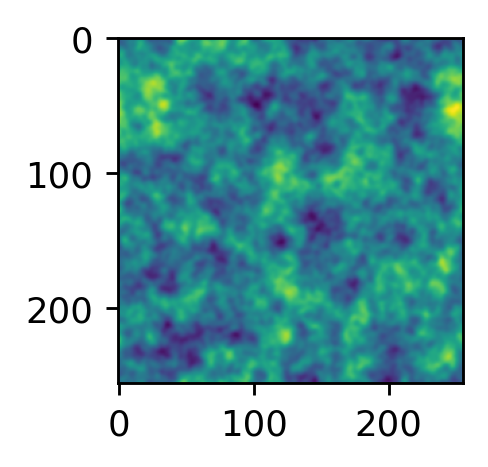

In [4]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 1, figsize=(3.5, 1.75), dpi=256)
ax.imshow(field)

In [5]:
mpi_lags = mpi_acf.get_all_lagvecs(tuple([N//2 for _ in range(D)]))

In [6]:
sf = statfunc_numba.process_lags(field, mpi_lags, 1)
sf = sf.reshape((N//2, N//2))

In [7]:
sf_naive = mpi_acf.process_lags(field, mpi_lags)
sf_naive = sf_naive.reshape((N//2, N//2))

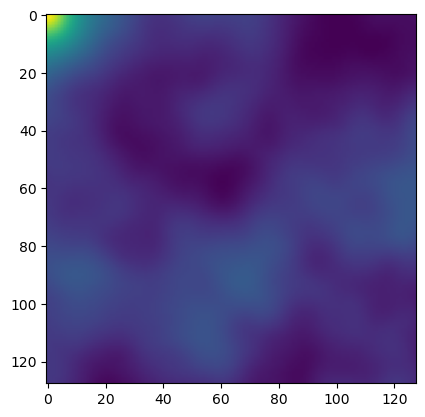

In [8]:
plt.imshow(sf)

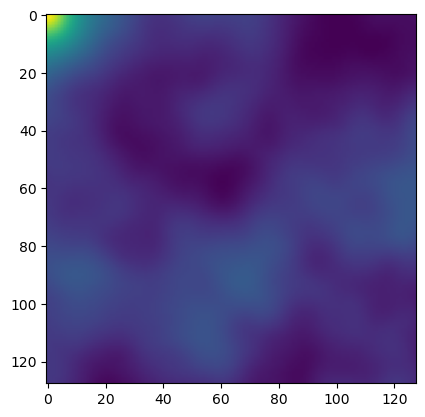

In [9]:
plt.imshow(sf_naive)

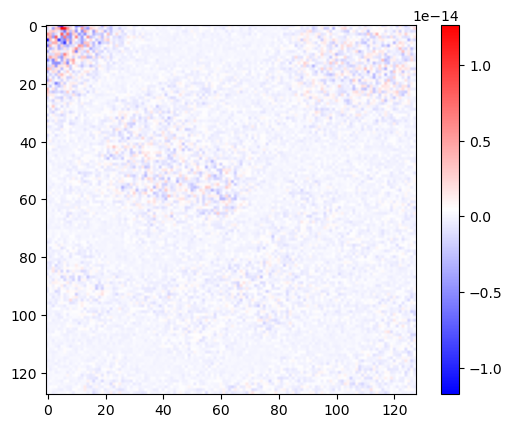

In [13]:
plt.imshow(sf_naive - sf, cmap='bwr')
plt.colorbar()

In [26]:
np.allclose(sf_naive, sf)

True